In [5]:
from google.colab import drive
import os

# 挂载 Google Drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
# 设置工作目录
WORK_DIR = '/content/drive/MyDrive/Assignment 3 - Bundle Adjustment'
os.chdir(WORK_DIR)
print("当前工作目录:", os.getcwd())

# 安装 PyTorch3D
import sys
import torch
pyt_version_str = torch.__version__.split("+")[0].replace(".", "")
version_str = "".join([f"py3{sys.version_info.minor}_cu", torch.version.cuda.replace(".", "")])
!pip install fvcore iopath
!pip install "git+https://github.com/facebookresearch/pytorch3d.git"

当前工作目录: /content/drive/MyDrive/Assignment 3 - Bundle Adjustment
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 3.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 4.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for fvcore: filename=fvcore-0.1.5.post20221221-py3-none-any.whl size=61397 sha256=6c04ca7950ff02615743ab8bbc7bbd7fd804c6700791260e19c3693705789559
  Stored in directory: /root/.cache/pip/wheels/ed/9f/a5/e4f5b27454ccd4596bd8b62432c7d6b1ca9fa22aef9d70a16a
  Created wheel for iopath: filename=iopath-0.1.10-py3-none-any.whl size=31527 sha256=aab224189b0063d6053f8b6c88c6e7e8a295eb463c44790aeca22018619a9b33
  Stored in directory: /root/.cache/pip/wheels/7c/96/04/4f5f31ff812f684f69f40cb1634357812220aac58d4698048c
Successfully built fvcore iopath
  Cloning https://github.com/facebookresearch/pytorch3d.git to /tmp/pip-req-build-t3m17gv0
  Running command git clone --filter=blob:

In [6]:
"""Visualize rendered images with projected 2D points overlaid.
Each point gets a unique color based on its index using OpenCV's applyColorMap."""

import numpy as np
import cv2
import os

OUTPUT_DIR = "data"
VIS_DIR = "data/vis"
os.makedirs(VIS_DIR, exist_ok=True)

points2d = np.load(f"{OUTPUT_DIR}/points2d.npz")

# generate a unique color per point via cv2.applyColorMap
sample_key = list(points2d.keys())[0]
n_points = len(points2d[sample_key])
indices = np.linspace(0, 255, n_points, dtype=np.uint8).reshape(1, -1)
colorbar = cv2.applyColorMap(indices, cv2.COLORMAP_HSV)  # (1, N, 3) BGR
colors = colorbar[0]  # (N, 3) BGR

# visualize selected views
for i in [0, 12, 25, 37, 49]:
    key = f"view_{i:03d}"
    img = cv2.imread(f"{OUTPUT_DIR}/images/{key}.png")

    obs = points2d[key]           # (N, 3): [x, y, visibility]
    pts = obs[:, :2]              # (N, 2)
    vis = obs[:, 2].astype(bool)  # (N,)

    for j in range(n_points):
        if vis[j]:
            x, y = int(pts[j, 0]), int(pts[j, 1])
            color = tuple(int(c) for c in colors[j])  # BGR
            cv2.circle(img, (x, y), 3, color, -1)

    cv2.imwrite(f"{VIS_DIR}/{key}_overlay.png", img)
    print(f"Saved {key}_overlay.png ({vis.sum()}/{n_points} visible)")

print("Done!")

Saved view_000_overlay.png (11114/20000 visible)
Saved view_012_overlay.png (16030/20000 visible)
Saved view_025_overlay.png (19550/20000 visible)
Saved view_037_overlay.png (16486/20000 visible)
Saved view_049_overlay.png (13108/20000 visible)
Done!


In [ ]:
import os
import glob
import shutil

# 设定 pip 的隐藏缓存目录
wheel_cache_dir = "/root/.cache/pip/wheels"

# 设定要保存到网盘的目录
drive_save_dir = "/content/drive/MyDrive/Assignment 3 - Bundle Adjustment/fast_install"
os.makedirs(drive_save_dir, exist_ok=True)

# 寻找编译好的 pytorch3d 文件
wheel_files = glob.glob(os.path.join(wheel_cache_dir, '**', 'pytorch3d*.whl'), recursive=True)

if wheel_files:
    for whl in wheel_files:
        shutil.copy(whl, drive_save_dir)
        print(f"提取成功！已保存到网盘: {os.path.basename(whl)}")
    print(f"保存路径: {drive_save_dir}")
else:
    print("没有找到文件")

没有找到文件


Using device: cuda
开始优化...
Epoch 0000 | Loss: 54256.8750 | f: 886.80
Epoch 0100 | Loss: 431.0052 | f: 887.29
Epoch 0200 | Loss: 39.6949 | f: 887.29
Epoch 0300 | Loss: 0.3230 | f: 887.29
Epoch 0400 | Loss: 0.0046 | f: 887.29
Epoch 0500 | Loss: 0.0001 | f: 887.29
Epoch 0600 | Loss: 0.0000 | f: 887.29
Epoch 0700 | Loss: 0.0000 | f: 887.29
Epoch 0800 | Loss: 0.0021 | f: 887.29
Epoch 0900 | Loss: 0.0010 | f: 887.29
Epoch 0999 | Loss: 0.0114 | f: 887.29


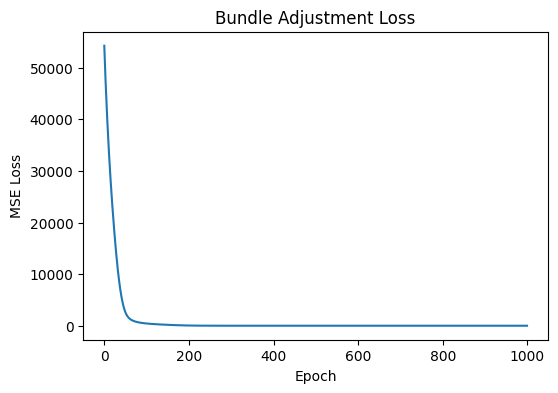

点云已导出: /content/drive/MyDrive/Assignment 3 - Bundle Adjustment/reconstructed_points.obj


In [8]:
# [Task 1 - Bundle Adjustment]
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import os
from pytorch3d.transforms import euler_angles_to_matrix

# 设置设备
torch.manual_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# 加载数据
data_path = 'data'
points2d_data = np.load(os.path.join(data_path, 'points2d.npz'))
points3d_colors = np.load(os.path.join(data_path, 'points3d_colors.npy'))

num_views = 50
num_points = 20000

# 构建真值张量
obs_2d = torch.zeros((num_views, num_points, 2), dtype=torch.float32, device=device)
mask = torch.zeros((num_views, num_points), dtype=torch.float32, device=device)

for i in range(num_views):
    view_key = f"view_{i:03d}"
    view_data = points2d_data[view_key]
    obs_2d[i] = torch.tensor(view_data[:, :2], dtype=torch.float32, device=device)
    mask[i] = torch.tensor(view_data[:, 2], dtype=torch.float32, device=device)

# 定义 BA 模型
class BundleAdjustmentModel(nn.Module):
    def __init__(self, num_views, num_points):
        super().__init__()
        # 初始化 3D 点在原点附近
        self.points_3d = nn.Parameter(torch.randn(num_points, 3) * 0.1)

        # 初始化外参 (Euler 角初始化为 0，即单位矩阵)
        self.camera_euler = nn.Parameter(torch.zeros(num_views, 3))
        # 平移初始化为 [0, 0, -2.5]
        t_init = torch.zeros(num_views, 3)
        t_init[:, 2] = -2.5
        self.camera_t = nn.Parameter(t_init)

        # 焦距 f 初始化 (假设 60度 FoV)
        f_init = 1024 / (2 * np.tan(np.radians(30)))
        self.focal_length = nn.Parameter(torch.tensor([f_init], dtype=torch.float32))

        self.cx, self.cy = 512.0, 512.0

    def forward(self):
        # 旋转矩阵 R: (V, 3, 3)
        R = euler_angles_to_matrix(self.camera_euler, convention="XYZ")

        # 坐标转换: P_cam = R @ P_3d + T
        P = self.points_3d.T.unsqueeze(0).expand(num_views, 3, num_points)
        P_cam = torch.baddbmm(self.camera_t.unsqueeze(2), R, P)

        Xc, Yc, Zc = P_cam[:, 0, :], P_cam[:, 1, :], P_cam[:, 2, :]

        # 投影 (X 取负号防止左右翻转)
        u = -self.focal_length * (Xc / Zc) + self.cx
        v = self.focal_length * (Yc / Zc) + self.cy

        return torch.stack([u, v], dim=-1)

# 开始优化
model = BundleAdjustmentModel(num_views, num_points).to(device)
optimizer = optim.Adam(model.parameters(), lr=0.01)

num_epochs = 1000
loss_history = []

print("开始优化...")
for epoch in range(num_epochs):
    optimizer.zero_grad()
    preds = model()

    # 计算重投影误差 MSE (仅考虑可见点)
    diff = (preds - obs_2d) ** 2
    loss = (diff.sum(dim=-1) * mask).sum() / mask.sum()

    loss.backward()
    optimizer.step()

    loss_history.append(loss.item())
    if epoch % 100 == 0 or epoch == num_epochs - 1:
        print(f"Epoch {epoch:04d} | Loss: {loss.item():.4f} | f: {model.focal_length.item():.2f}")

# 可视化与保存
plt.figure(figsize=(6, 4))
plt.plot(loss_history)
plt.title("Bundle Adjustment Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.show()

# 导出带颜色的 OBJ 点云
points_opt = model.points_3d.detach().cpu().numpy()
output_obj = 'reconstructed_points.obj'
with open(output_obj, 'w') as f:
    for p, c in zip(points_opt, points3d_colors):
        f.write(f"v {p[0]:.6f} {p[1]:.6f} {p[2]:.6f} {c[0]:.6f} {c[1]:.6f} {c[2]:.6f}\n")
print(f"点云已导出: {os.path.abspath(output_obj)}")

In [9]:
import torch
from pytorch3d.transforms import euler_angles_to_matrix

# 提取优化后的参数
with torch.no_grad():
    # 焦距 f
    f_final = model.focal_length.item()

    # 外参 R (从欧拉角转为 3x3 矩阵)
    R_final = euler_angles_to_matrix(model.camera_euler, convention="XYZ").cpu().numpy()

    # 外参 T
    T_final = model.camera_t.cpu().numpy()

    # 3D 点坐标
    points_3d_final = model.points_3d.cpu().numpy()

# 打印关键数值
print("-" * 30)
print(f"优化完成，输出参数摘要：")
print(f"相机焦距 f: {f_final:.4f}")
print(f"相机外参 R 形状: {R_final.shape} (50 组 3x3 矩阵)")
print(f"相机外参 T 形状: {T_final.shape} (50 组 3 维向量)")
print(f"3D 点坐标形状: {points_3d_final.shape} (20000 个点)")
print("-" * 30)

# 将结果保存到文件
output_dir = 'task1_results'
os.makedirs(output_dir, exist_ok=True)

# 保存为 numpy 格式
np.save(f'{output_dir}/focal_length.npy', f_final)
np.save(f'{output_dir}/extrinsics_R.npy', R_final)
np.save(f'{output_dir}/extrinsics_T.npy', T_final)
np.save(f'{output_dir}/points_3d.npy', points_3d_final)

# 查看前 3 个相机参数
with open(f'{output_dir}/camera_params_report.txt', 'w') as f_report:
    f_report.write(f"Task 1 Optimization Report\n")
    f_report.write(f"Optimized Focal Length f: {f_final:.6f}\n\n")
    for i in range(3): # 示例前三个相机
        f_report.write(f"--- Camera {i:03d} ---\n")
        f_report.write(f"Rotation Matrix R:\n{R_final[i]}\n")
        f_report.write(f"Translation Vector T: {T_final[i]}\n\n")

print(f"所有结果已保存至文件夹: {os.path.abspath(output_dir)}")

------------------------------
优化完成，输出参数摘要：
相机焦距 f: 887.2908
相机外参 R 形状: (50, 3, 3) (50 组 3x3 矩阵)
相机外参 T 形状: (50, 3) (50 组 3 维向量)
3D 点坐标形状: (20000, 3) (20000 个点)
------------------------------
所有结果已保存至文件夹: /content/drive/MyDrive/Assignment 3 - Bundle Adjustment/task1_results


In [11]:
!pip install -q condacolab
import condacolab
condacolab.install()

⏬ Downloading https://github.com/jaimergp/miniforge/releases/download/24.11.2-1_colab/Miniforge3-colab-24.11.2-1_colab-Linux-x86_64.sh...
📦 Installing...
📌 Adjusting configuration...
🩹 Patching environment...
⏲ Done in 0:00:09
🔁 Restarting kernel...


In [1]:
import os
from google.colab import drive

# 挂载 Google Drive
drive.mount('/content/drive')
%cd "/content/drive/MyDrive/Assignment 3 - Bundle Adjustment"

# 使用 conda 安装带 CUDA 版本的 COLMAP
!conda install -y -c conda-forge colmap

print("----------------------------------------")
!colmap help | grep CUDA

流式输出内容被截断，只能显示最后 5000 行内容。
  libxml2                                 2.13.5-h0d44e9d_1 --> 2.13.9-h04c0eec_0 
  libzlib                                  1.3.1-hb9d3cd8_2 --> 1.3.2-h25fd6f3_2 
  openssl                                  3.4.0-h7b32b05_1 --> 3.6.2-h35e630c_0 
  zstandard                          0.23.0-py311hbc35293_1 --> 0.25.0-py311haee01d2_1 
  zstd                                     1.5.6-ha6fb4c9_0 --> 1.5.7-hb78ec9c_6 



libcublas-12.9.1.4   | 446.1 MB  | :   0% 0/1 [00:00<?, ?it/s]
libcusparse-12.5.10. | 199.2 MB  | :   0% 0/1 [00:00<?, ?it/s]

libcusolver-11.7.5.8 | 195.6 MB  | :   0% 0/1 [00:00<?, ?it/s]


onnxruntime-cpp-1.24 | 183.7 MB  | :   0% 0/1 [00:00<?, ?it/s]



colmap-4.0.3         | 132.8 MB  | :   0% 0/1 [00:00<?, ?it/s]




cuda-nvrtc-12.9.86   | 64.1 MB   | :   0% 0/1 [00:00<?, ?it/s]





qt-main-5.15.15      | 50.2 MB   | :   0% 0/1 [00:00<?, ?it/s]






libcurand-10.3.10.19 | 44.1 MB   | :   0% 0/1 [00:00<?, ?it/s]







libllvm21-21.1.0     

In [10]:
%%bash
# 自动安装 COLMAP 环境
echo "正在检查并安装 COLMAP 环境..."
apt-get update > /dev/null
apt-get install -y colmap > /dev/null

export QT_QPA_PLATFORM="offscreen"

# 确保进入主目录
cd "/content/drive/MyDrive/Assignment 3 - Bundle Adjustment"
echo "当前运行目录: $(pwd)"
echo "----------------------------------------"

set -e

DATASET_PATH="data"
IMAGE_PATH="$DATASET_PATH/images"
COLMAP_PATH="$DATASET_PATH/colmap"

mkdir -p "$COLMAP_PATH/sparse"
mkdir -p "$COLMAP_PATH/dense"

echo "=== Step 1: Feature Extraction ==="
colmap feature_extractor \
    --database_path "$COLMAP_PATH/database.db" \
    --image_path "$IMAGE_PATH" \
    --ImageReader.camera_model PINHOLE \
    --ImageReader.single_camera 1 \
    --SiftExtraction.use_gpu 0

echo "=== Step 2: Feature Matching ==="
colmap exhaustive_matcher \
    --database_path "$COLMAP_PATH/database.db" \
    --SiftMatching.use_gpu 0

echo "=== Step 3: Sparse Reconstruction (Bundle Adjustment) ==="
colmap mapper \
    --database_path "$COLMAP_PATH/database.db" \
    --image_path "$IMAGE_PATH" \
    --output_path "$COLMAP_PATH/sparse"

echo "=== Step 4: Image Undistortion ==="
colmap image_undistorter \
    --image_path "$IMAGE_PATH" \
    --input_path "$COLMAP_PATH/sparse/0" \
    --output_path "$COLMAP_PATH/dense"

echo "=== Step 5: Dense Reconstruction (Patch Match Stereo) ==="
colmap patch_match_stereo \
    --workspace_path "$COLMAP_PATH/dense"

echo "=== Step 6: Stereo Fusion ==="
colmap stereo_fusion \
    --workspace_path "$COLMAP_PATH/dense" \
    --output_path "$COLMAP_PATH/dense/fused.ply"

echo "=== Done! ==="
echo "Results:"
echo "  Sparse: $COLMAP_PATH/sparse/0/"
echo "  Dense:  $COLMAP_PATH/dense/fused.ply"


正在检查并安装 COLMAP 环境...
当前运行目录: /content/drive/MyDrive/Assignment 3 - Bundle Adjustment
----------------------------------------
=== Step 1: Feature Extraction ===

Feature extraction

Processed file [1/50]
  Name:            view_000.png
  Dimensions:      1024 x 1024
  Camera:          #1 - PINHOLE
  Focal Length:    1228.80px
  Features:        388
Processed file [2/50]
  Name:            view_001.png
  Dimensions:      1024 x 1024
  Camera:          #1 - PINHOLE
  Focal Length:    1228.80px
  Features:        365
Processed file [3/50]
  Name:            view_002.png
  Dimensions:      1024 x 1024
  Camera:          #1 - PINHOLE
  Focal Length:    1228.80px
  Features:        363
Processed file [4/50]
  Name:            view_003.png
  Dimensions:      1024 x 1024
  Camera:          #1 - PINHOLE
  Focal Length:    1228.80px
  Features:        367
Processed file [5/50]
  Name:            view_004.png
  Dimensions:      1024 x 1024
  Camera:          #1 - PINHOLE
  Focal Length:    1228.8

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
ERROR: Dense stereo reconstruction requires CUDA, which is not available on your system.


CalledProcessError: Command 'b'# \xe8\x87\xaa\xe5\x8a\xa8\xe5\xae\x89\xe8\xa3\x85 COLMAP \xe7\x8e\xaf\xe5\xa2\x83\necho "\xe6\xad\xa3\xe5\x9c\xa8\xe6\xa3\x80\xe6\x9f\xa5\xe5\xb9\xb6\xe5\xae\x89\xe8\xa3\x85 COLMAP \xe7\x8e\xaf\xe5\xa2\x83..."\napt-get update > /dev/null\napt-get install -y colmap > /dev/null\n\nexport QT_QPA_PLATFORM="offscreen"\n\n# \xe7\xa1\xae\xe4\xbf\x9d\xe8\xbf\x9b\xe5\x85\xa5\xe4\xb8\xbb\xe7\x9b\xae\xe5\xbd\x95\ncd "/content/drive/MyDrive/Assignment 3 - Bundle Adjustment"\necho "\xe5\xbd\x93\xe5\x89\x8d\xe8\xbf\x90\xe8\xa1\x8c\xe7\x9b\xae\xe5\xbd\x95: $(pwd)"\necho "----------------------------------------"\n\nset -e\n\nDATASET_PATH="data"\nIMAGE_PATH="$DATASET_PATH/images"\nCOLMAP_PATH="$DATASET_PATH/colmap"\n\nmkdir -p "$COLMAP_PATH/sparse"\nmkdir -p "$COLMAP_PATH/dense"\n\necho "=== Step 1: Feature Extraction ==="\ncolmap feature_extractor \\\n    --database_path "$COLMAP_PATH/database.db" \\\n    --image_path "$IMAGE_PATH" \\\n    --ImageReader.camera_model PI

In [4]:
import os

# 补全缺失的库
!conda install -y -c conda-forge faiss-cpu > /dev/null

import glob
# 在 conda 路径下搜索这个库
found_paths = glob.glob('/usr/local/lib/libfaiss.so*')
if not found_paths:
    found_paths = glob.glob('/usr/local/pkgs/**/libfaiss.so*', recursive=True)

if found_paths:
    lib_dir = os.path.dirname(found_paths[0])
    os.environ["LD_LIBRARY_PATH"] = f"{lib_dir}:/usr/local/lib:" + os.environ.get("LD_LIBRARY_PATH", "")
    print(f"已定位库路径: {lib_dir}")

# 环境变量与目录切换
os.environ["QT_QPA_PLATFORM"] = "offscreen"
%cd "/content/drive/MyDrive/Assignment 3 - Bundle Adjustment"

# 执行重建
print("\n 启动稠密重建 (Step 5)...")
!colmap patch_match_stereo --workspace_path data/colmap/dense

print("\n 启动点云融合 (Step 6)...")
!colmap stereo_fusion --workspace_path data/colmap/dense --output_path data/colmap/dense/fused.ply

print("\n 如果看到 'Done!'，请去网盘下载 data/colmap/dense/fused.ply")

流式输出内容被截断，只能显示最后 5000 行内容。
I20260422 05:58:02.646997 139859133239296 cudacc.cc:51]  Sweep 1: 0.5367s
I20260422 05:58:03.288189 139859133239296 cudacc.cc:51]  Sweep 2: 0.6411s
I20260422 05:58:03.819307 139859133239296 cudacc.cc:51]  Sweep 3: 0.5311s
I20260422 05:58:04.459325 139859133239296 cudacc.cc:51]  Sweep 4: 0.6400s
I20260422 05:58:04.459389 139859133239296 cudacc.cc:51] Iteration 4: 2.3492s
I20260422 05:58:04.989912 139859133239296 cudacc.cc:51]  Sweep 1: 0.5305s
I20260422 05:58:05.621162 139859133239296 cudacc.cc:51]  Sweep 2: 0.6312s
I20260422 05:58:06.147265 139859133239296 cudacc.cc:51]  Sweep 3: 0.5260s
I20260422 05:58:06.776051 139859133239296 cudacc.cc:51]  Sweep 4: 0.6287s
I20260422 05:58:06.776105 139859133239296 cudacc.cc:51] Iteration 5: 2.3167s
I20260422 05:58:06.776131 139859133239296 cudacc.cc:51] Total: 11.9949s
I20260422 05:58:06.776147 139859133239296 patch_match.cc:525] 
Writing photometric output for view_018.png
I20260422 05:58:07.153525 139859133239296 patch_